In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#분석을 위한
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline   # 스케일링 + 모델을 한번에 연결하는 파이프라인 기능을 위함
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier # 여러 모델을 결합하는 Voting 앙상블 모델을 사용하기 위함

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [6]:
# 2. iris 데이터 로드 및 학습데이터 분할

iris = load_iris()
X = iris.data # x data
y = iris.target # y data
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split (
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
# 개념 모델 정의 (SVM, KNN, RandomForest)

# SVM
svm_clf = make_pipeline(     #make_pipeline : 입력값의 StandardScaler 적용과 함께 모델을 파이프라인으로 묶어 사용
    StandardScaler(),
    SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
) #SVM 분류모델

# KNN
knn_clf = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

# RandomForest
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
) # 트리 기반 분류 모델이라 구조가 다름

# 3개의 모델을 soft voting 방식으로 결합한 votingclassifier
voting_clf = VotingClassifier(
    estimators=[('svm', svm_clf), ('knn', knn_clf), ('rf', rf_clf)],
    voting = 'soft',
    weights=[1,1,2]
)

In [8]:
# 모델 학습(fit)

svm_clf.fit(X_train, y_train)
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
voting_clf.fit(X_train, y_train)

,estimators,"[('svm', ...), ('knn', ...), ...]"
,voting,'soft'
,weights,"[1, 1, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'


In [9]:
# 모델 평가 및 정확도 출력
y_pred = voting_clf.predict(X_test)  # 테스트 데이터를 넣어 앙상블 모델로 예측 결과 출력
accuracy = accuracy_score(y_test, y_pred)

print("==voitng classifier==")
print("accuracy : ", round(accuracy, 4))

==voitng classifier==
accuracy :  0.9


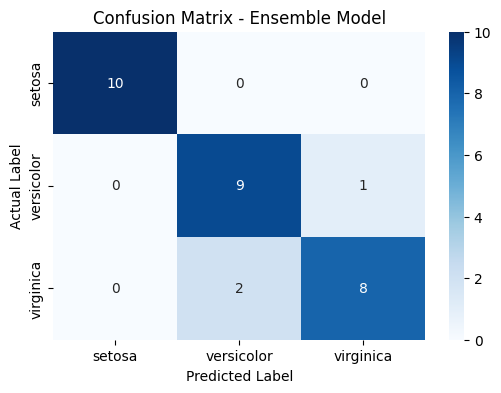

In [10]:
# confusion matrix 시각화
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix - Ensemble Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

C:\Users\ui203\AppData\Local\Temp\ipykernel_21372\2842511456.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_f1, x='class', y='f1', palette='viridis')


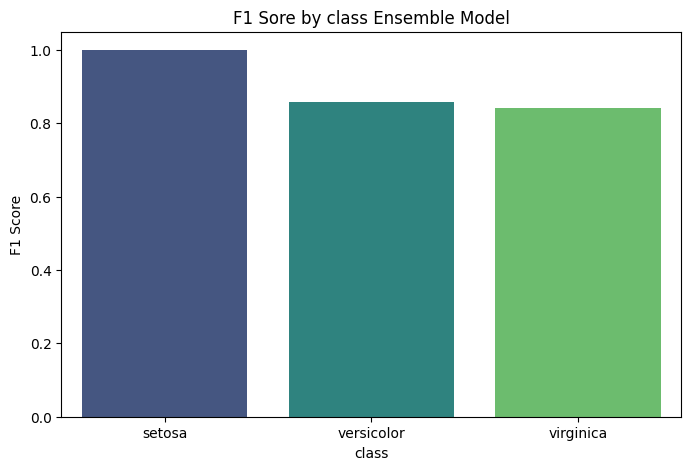

In [11]:
#confusion에서 확인할 수 있는 메트릭스 3가지
#Accuracy → 전체 성능                 (정확도)
#Precision → "맞다고 한 게 진짜 맞냐" (정밀도) -> 정확도 정말 잘 측정된게 맞니? 검사 받아라 같은 느낌
#Recall → "진짜를 얼마나 잘 잡았냐"   (재현율)
# classification
report = classification_report(
    y_test, y_pred,
    target_names=class_names,
    output_dict=True
)

# class 별 f1-score만 리스트로 받아옴
f1_score= [report[c]['f1-score'] for c in class_names]

df_f1 = pd.DataFrame({'class' : class_names, 'f1': f1_score})

plt.figure(figsize=(8,5))
sns.barplot(data=df_f1, x='class', y='f1', palette='viridis')

plt.title('F1 Sore by class Ensemble Model')
plt.xlabel("class")
plt.ylabel("F1 Score")
plt.show()

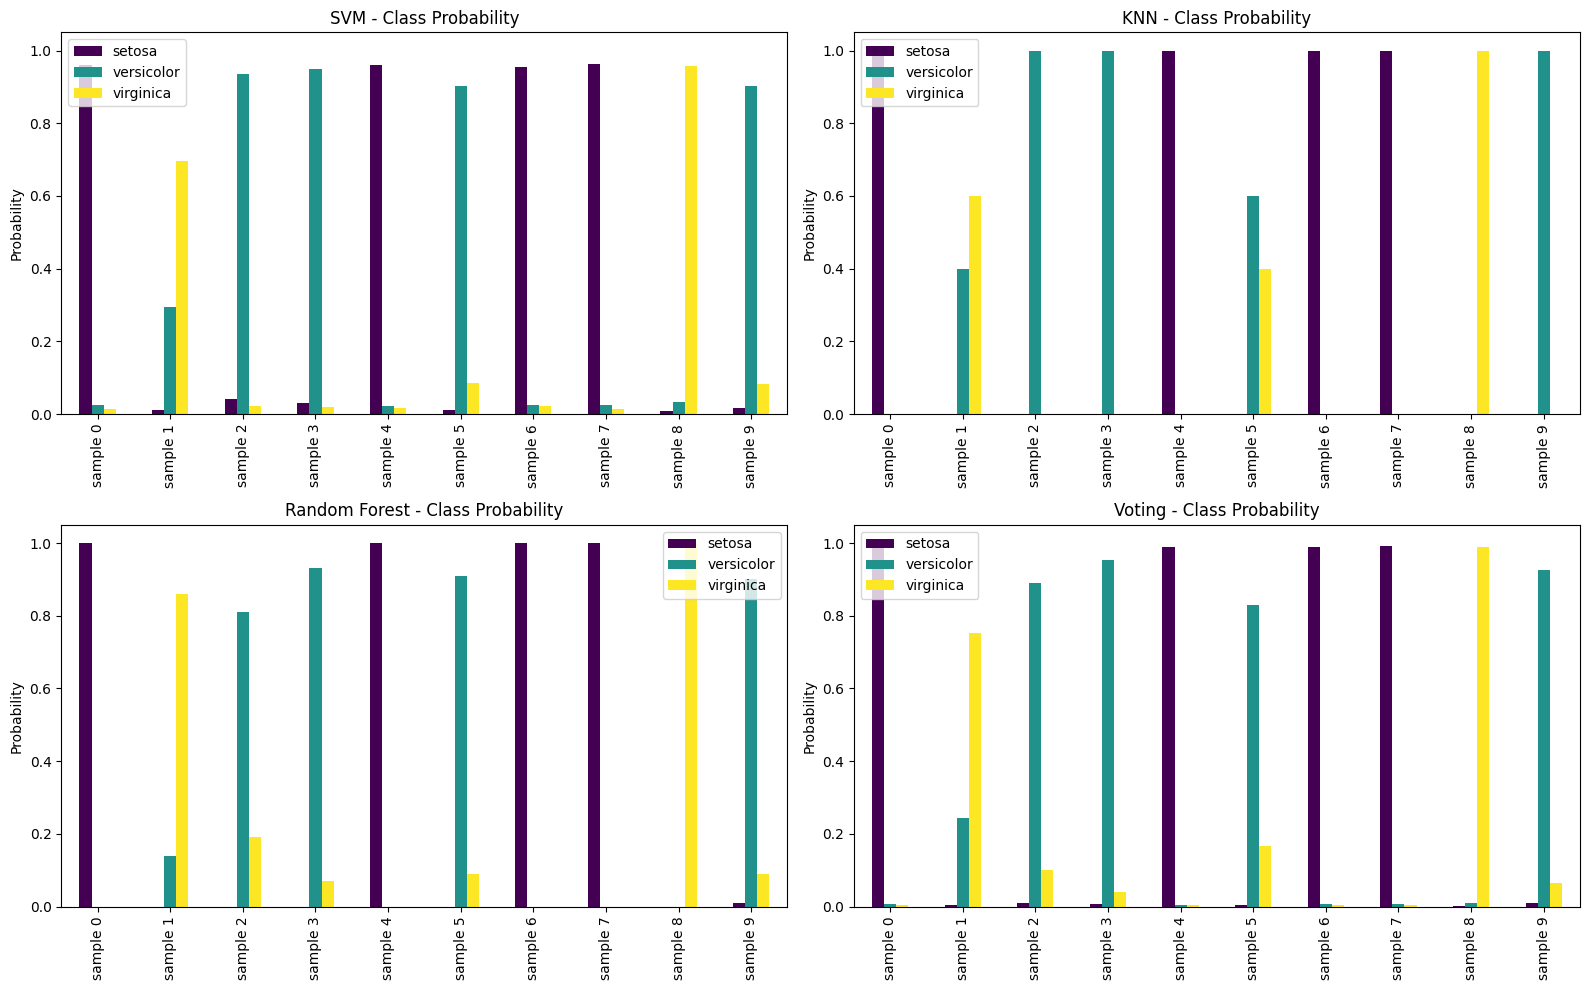

In [12]:
# 모델별 예측 확률 시각화
idx = np.arange(10)   # 10 개 샘플 인덱스 생성
X_sample = X_test[idx]
y_sample = y_test[idx]

proba_svm = svm_clf.predict_proba(X_sample)   # svm의 예측 확률
proba_knn = knn_clf.predict_proba(X_sample)   # knn의 예측 확률
proba_rf = rf_clf.predict_proba(X_sample)   # rf의 예측 확률
proba_vote = voting_clf.predict_proba(X_sample)   # voting의 예측 확률

model_names = ["SVM", "KNN", "Random Forest", "Voting"]
proba_list = [proba_svm, proba_knn, proba_rf, proba_vote]

plt.figure(figsize=(16,10))

for i, (model_name, proba) in enumerate(zip(model_names, proba_list)):
    plt.subplot(2,2,i+1)
    df_prob = pd.DataFrame(proba, columns=class_names)
    df_prob.index = [f'sample {i}' for i in range(len(df_prob))]

    df_prob.plot(kind='bar', ax=plt.gca(), colormap='viridis')
    plt.ylabel('Probability')
    plt.ylim(0, 1.05)
    plt.title(f'{model_name} - Class Probability')
    plt.tight_layout()

plt.show()

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

np.random.seed(42)

# 제조 공정 품질 이상 분류 모델 개발 실습
# --> 가상 제조 공정 데이터를 기반으로, 제품이 정상(0)인지 불량(1)인지 예측하는 모델 개발5
jejo = 1500
temp = np.random.normal(20, 5, jejo)      #uniform(최소,최대,갯수)          #온도
pressure = np.random.uniform(5, 7, jejo)                                     #압력              
vibration = np.random.normal(4.5, 1.2, jejo) #normal(값,표준편차,갯수)       #진동
torque = np.random.uniform(200, 255, jejo)                                  #토크 (돌리는 힘)
rotation_speed = np.random.normal(1500,250, jejo)                           #회전 속도
humidity = np.random.uniform(33, 57, jejo)                                  #습도
operator = np.random.uniform(1, 20, jejo)                                   #사람 년차

#choice (갯수, 크기, [replace = True or False (중복 허용 할거야?)]
missing_temp = np.random.choice(jejo, 150, replace=False)        
missing_pressure = np.random.choice(jejo, 150, replace=False)
missing_vibration = np.random.choice(jejo, 150, replace=False)
missing_torque = np.random.choice(jejo, 150, replace=False)
missing_rotation_speed = np.random.choice(jejo, 150, replace=False)
missing_humidity = np.random.choice(jejo, 150, replace=False)
missing_operator = np.random.choice(jejo, 150, replace=False)

#범주형 변수 생성
machine_type = np.random.choice(['CNC', 'CM', 'FPM'], jejo, p=[0.32, 0.35, 0.33]) # 고정밀 부품 가공 기계, 재료 가공 기계, 재료 물리 변형 기
shift = np.random.choice(['day', 'night'], jejo, p=[0.6, 0.4]) #근무자들 주/야간 ?
material_grade = np.random.choice(['low', 'medium', 'high'], jejo, p=[0.2, 0.5, 0.3]) #기계들의 강도?

# 미싱 데이터를 원본값에 집어넣음. (원본에 결측치 데이터 삽입)
temp[missing_temp] = np.nan
pressure[missing_pressure] = np.nan
vibration[missing_vibration] = np.nan
torque[missing_torque] = np.nan
rotation_speed[missing_rotation_speed] = np.nan
humidity[missing_humidity] = np.nan
operator[missing_operator] = np.nan

# 비율 생성
temp_pressure = (temp / pressure)                                   # 비율 = #온도  / 압력
vibration_torque_interaction = (vibration * torque)                 # 진동 * 토크 
energy = (torque * rotation_speed)                                  # 토크 * (#회전 속도)
temp_humidity_gap = (temp - humidity)                               # 온도 - (#습도)
machine_stress_index = (pressure * vibration) / (operator + 1)    # (압력 * 진동) / (["사람" + 1])

y = (defect_score > np.nanmedian(defect_score)).astype(int)

# DataFrame 생성
df = pd.DataFrame({
    'temp': temp,
    'pressure': pressure,
    'vibration': vibration,
    'torque': torque,
    'rotation_speed': rotation_speed,
    'humidity': humidity,
    'operator': operator,
    'machine_type': machine_type,
    'shift': shift,
    'material_grade': material_grade,
    'temp_pressure': temp_pressure,
    'vibration_torque_interaction': vibration_torque_interaction,
    'energy': energy,
    'temp_humidity_gap': temp_humidity_gap,
    'machine_stress_index': machine_stress_index
})

# 범주형 원핫 인코딩 진행
X = df
y = y

num_cols = [
    'temp', 'pressure', 'vibration', 'torque', 'rotation_speed',
    'humidity', 'operator', 'temp_pressure', 'vibration_torque_interaction',
    'energy', 'temp_humidity_gap', 'machine_stress_index'
]

cat_cols = ['machine_type', 'shift', 'material_grade']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# 분류 모델 3종류 (회귀도 가능한 모델들)
# SVM
svm_clf = make_pipeline(     #make_pipeline : 입력값의 StandardScaler 적용과 함께 모델을 파이프라인으로 묶어 사용
    StandardScaler(),
    SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
) #SVM 분류모델

# KNN
knn_clf = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
) #KNN 분류 모델

# RandomForest
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
) # [트리 기반 분류 모델이라 두 모델과 구조가 다름]

ValueError: Shape of passed values is (10, 3), indices imply (10, 2)

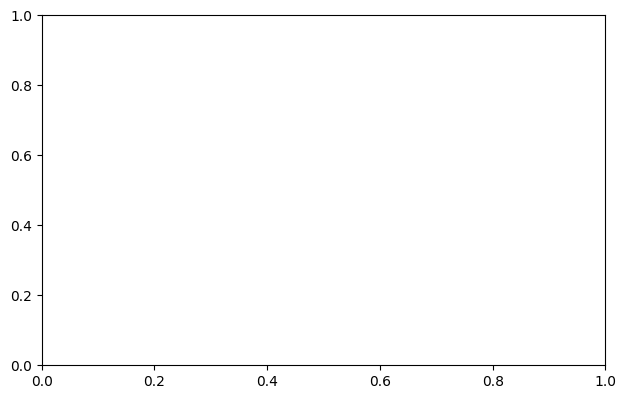

In [51]:
# 학습
svm_clf.fit(X_train, y_train)
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

# 샘플 선택
idx = np.arange(10)
X_sample = X_test[idx]

# 예측 확률
proba_svm = svm_clf.predict_proba(X_sample)
proba_knn = knn_clf.predict_proba(X_sample)
proba_rf = rf_clf.predict_proba(X_sample)

class_names = ['Normal', 'Defect']
model_names = ["SVM", "KNN", "Random Forest"]
proba_list = [proba_svm, proba_knn, proba_rf]

plt.figure(figsize=(16, 10))

for i, (model_name, proba) in enumerate(zip(model_names, proba_list)):
    plt.subplot(2, 2, i+1)

    df_prob = pd.DataFrame(proba, columns=class_names)
    df_prob.index = [f'sample {j}' for j in range(len(df_prob))]

    df_prob.plot(kind='bar', ax=plt.gca(), colormap='viridis')
    plt.ylabel('Probability')
    plt.ylim(0, 1.05)
    plt.title(f'{model_name} - Class Probability')

plt.tight_layout()
plt.show()